

---
<br>

# **Chapter 1: Retention analysis**

<br>



## Import packages and data

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))  # repo root: the `datadiner` package lives there

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from IPython.display import Image, display

from datadiner import (
    retention_counts_heatmap,
    retention_rate_heatmap,
    churn_counts_heatmap,
    churn_rate_heatmap,
    vs_average_heatmap,
    retention_curve,
    lifecycle_states,
    usage_frequency
)


In [4]:
from datadiner.io import load_events

# Datasets live in datasets/<name>/; the repo root is on sys.path (cell above).
df = load_events('../../datasets/chess/chess_games_events.csv')
df['event_type'] = 'game_played'
df.head()

,user_id,event_time,event_type,date,week,abs_week,segment,acquisition_channel,country,platform
0,user_000045,2024-01-01 00:06:59,game_played,2024-01-01,2024-01-01,0,power,organic,US,android
1,user_000249,2024-01-01 00:09:24,game_played,2024-01-01,2024-01-01,0,core,organic,RU,web
2,user_000127,2024-01-01 00:15:50,game_played,2024-01-01,2024-01-01,0,core,social,IN,android
3,user_000144,2024-01-01 00:43:42,game_played,2024-01-01,2024-01-01,0,casual,referral,US,ios
4,user_000024,2024-01-01 00:54:23,game_played,2024-01-01,2024-01-01,0,core,social,UK,android


In [5]:

df['month'] = df['date'].dt.to_period('M')
df['week'] = df['date'].dt.to_period('W')

# --- Assign each user to a weekly/monthly cohort based on their first activity ---
first_activity = df.groupby('user_id')['week'].min().reset_index()
first_activity.columns = ['user_id', 'cohort_week']
df = df.merge(first_activity[['user_id', 'cohort_week']], on='user_id')

first_month = df.groupby('user_id')['month'].min().reset_index()
first_month.columns = ['user_id', 'cohort_month']
df = df.merge(first_month, on='user_id')


df = df[df.date < '2024-12-01']

df.head()

,user_id,event_time,event_type,date,week,abs_week,segment,acquisition_channel,country,platform,month,cohort_week,cohort_month
0,user_000045,2024-01-01 00:06:59,game_played,2024-01-01,2024-01-01/2024-01-07,0,power,organic,US,android,2024-01,2024-01-01/2024-01-07,2024-01
1,user_000249,2024-01-01 00:09:24,game_played,2024-01-01,2024-01-01/2024-01-07,0,core,organic,RU,web,2024-01,2024-01-01/2024-01-07,2024-01
2,user_000127,2024-01-01 00:15:50,game_played,2024-01-01,2024-01-01/2024-01-07,0,core,social,IN,android,2024-01,2024-01-01/2024-01-07,2024-01
3,user_000144,2024-01-01 00:43:42,game_played,2024-01-01,2024-01-01/2024-01-07,0,casual,referral,US,ios,2024-01,2024-01-01/2024-01-07,2024-01
4,user_000024,2024-01-01 00:54:23,game_played,2024-01-01,2024-01-01/2024-01-07,0,core,social,UK,android,2024-01,2024-01-01/2024-01-07,2024-01


# Defining Your Core Metric

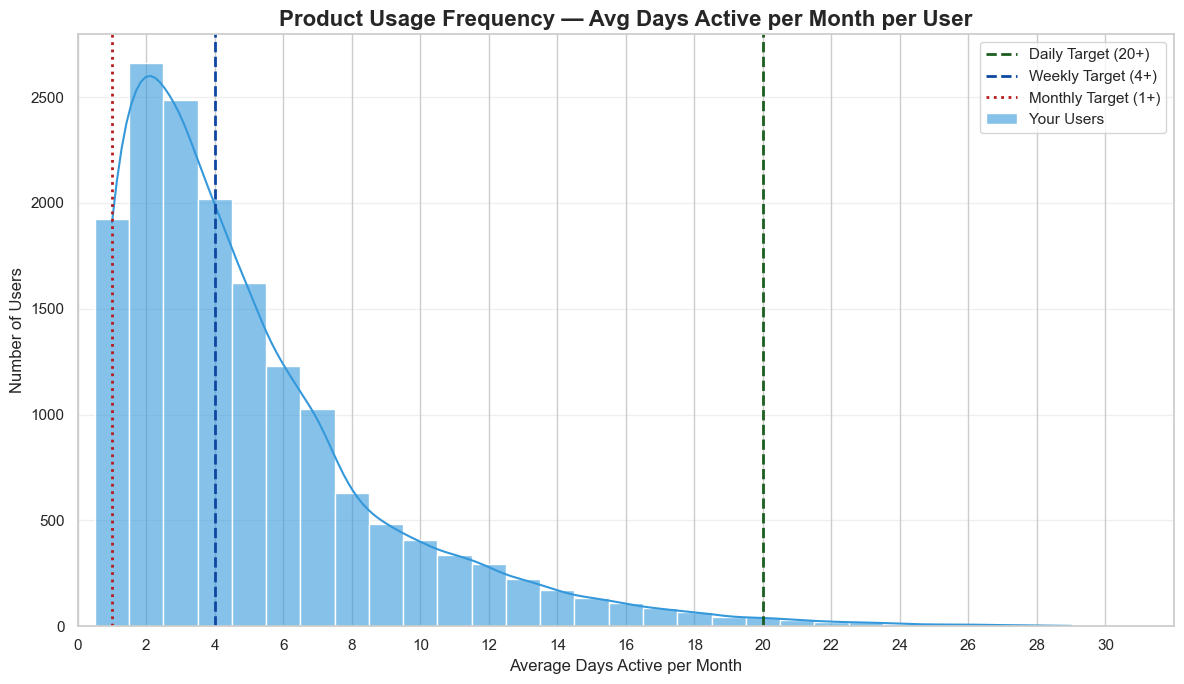

In [6]:
# Usage frequency — avg days active per month per user
fig, ax, avg_days = usage_frequency(df)

# Visualizing the Retention

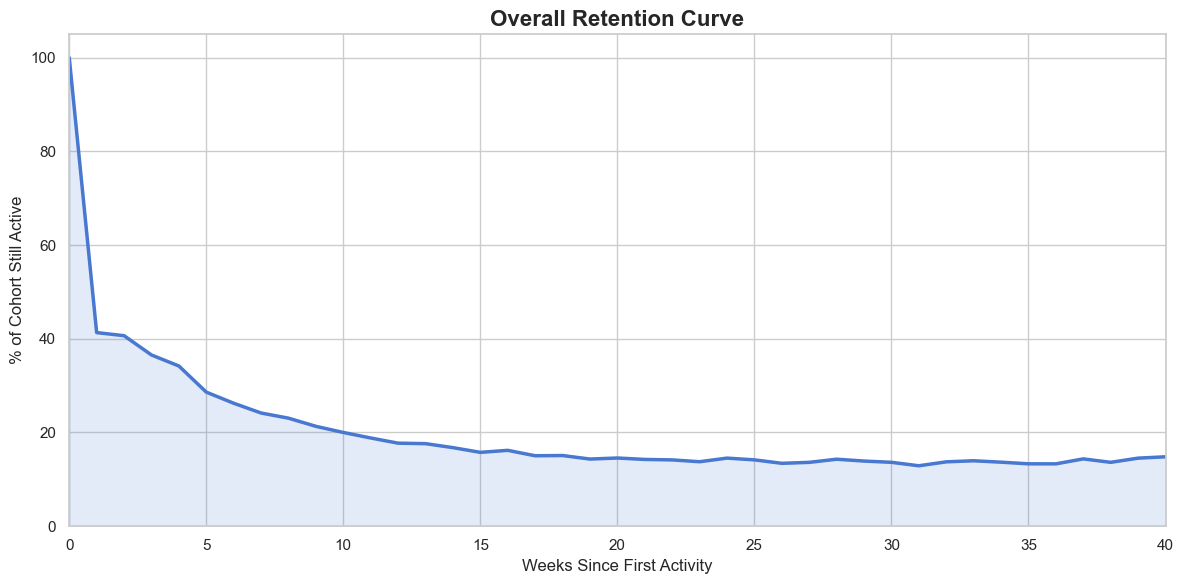

In [7]:
# Overall retention curve
fig, ax = retention_curve(df)

# User Lifecycle Stages 

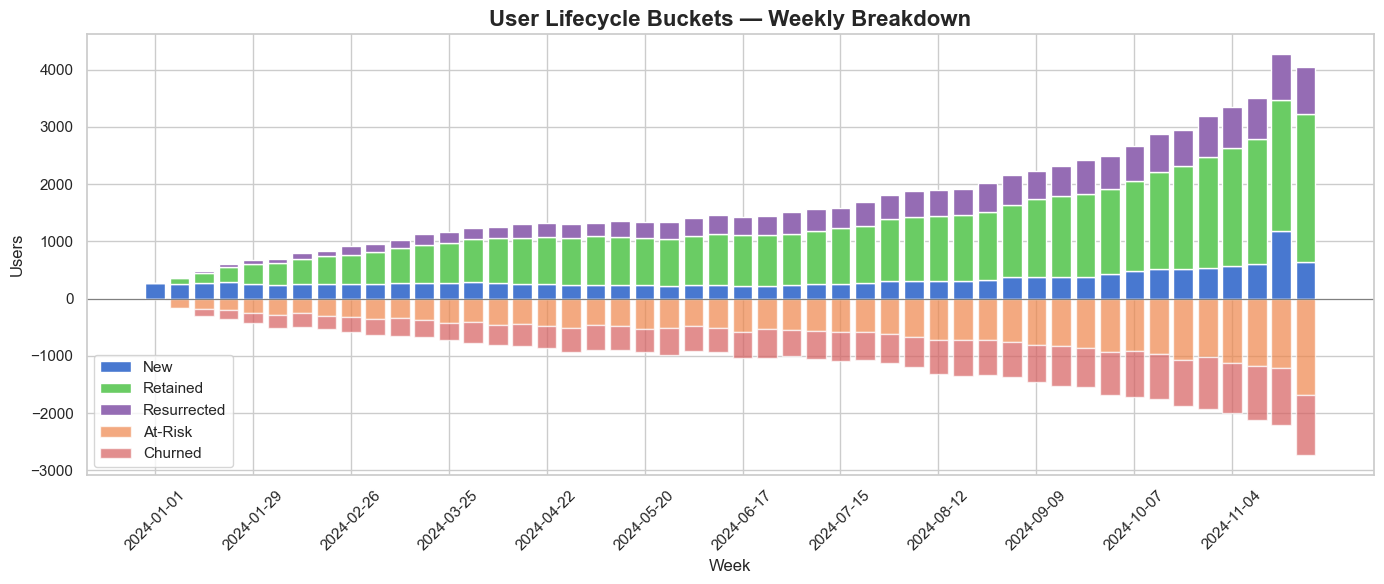

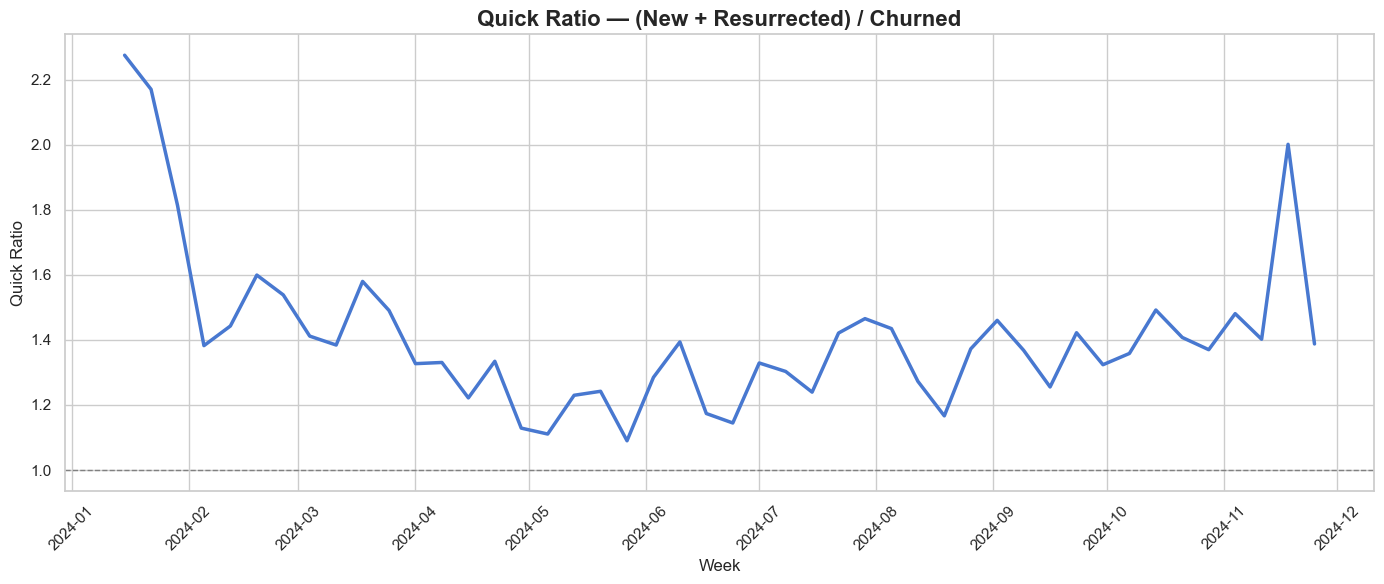

In [8]:
# Lifecycle states — 3 charts
states_df, figs = lifecycle_states(df)

# Cohort analysis

#### Synthetic data and shocks:

**Acquisition:** ~10,000 new users/month (2,500/week) with some variance, flat throughout the year.

**NURR:** new user retention rate, % of users active after their first week

**CURR:** current user retention rate, % of users active if they were active on the previous week

| Cohort Weeks | Story | Effect |
|:---:|:---:|:---|
| Marc | Bad marketing campaign | NURR drops to 0.12, CURR offset -0.10 — these users churn fast |
| April | Marketing budget cut | Number of new users decreased |
| May 20 - July 20 | New onboarding flow | NURR jumps to 0.60 — new users retain much better |
| Sep 16 | OpenAI outage - AI feature is down | lost 30% of the weekly active users  |
| All time | Gradual product improvement | CURR rises linearly from 0.78 → 0.86 across the year |


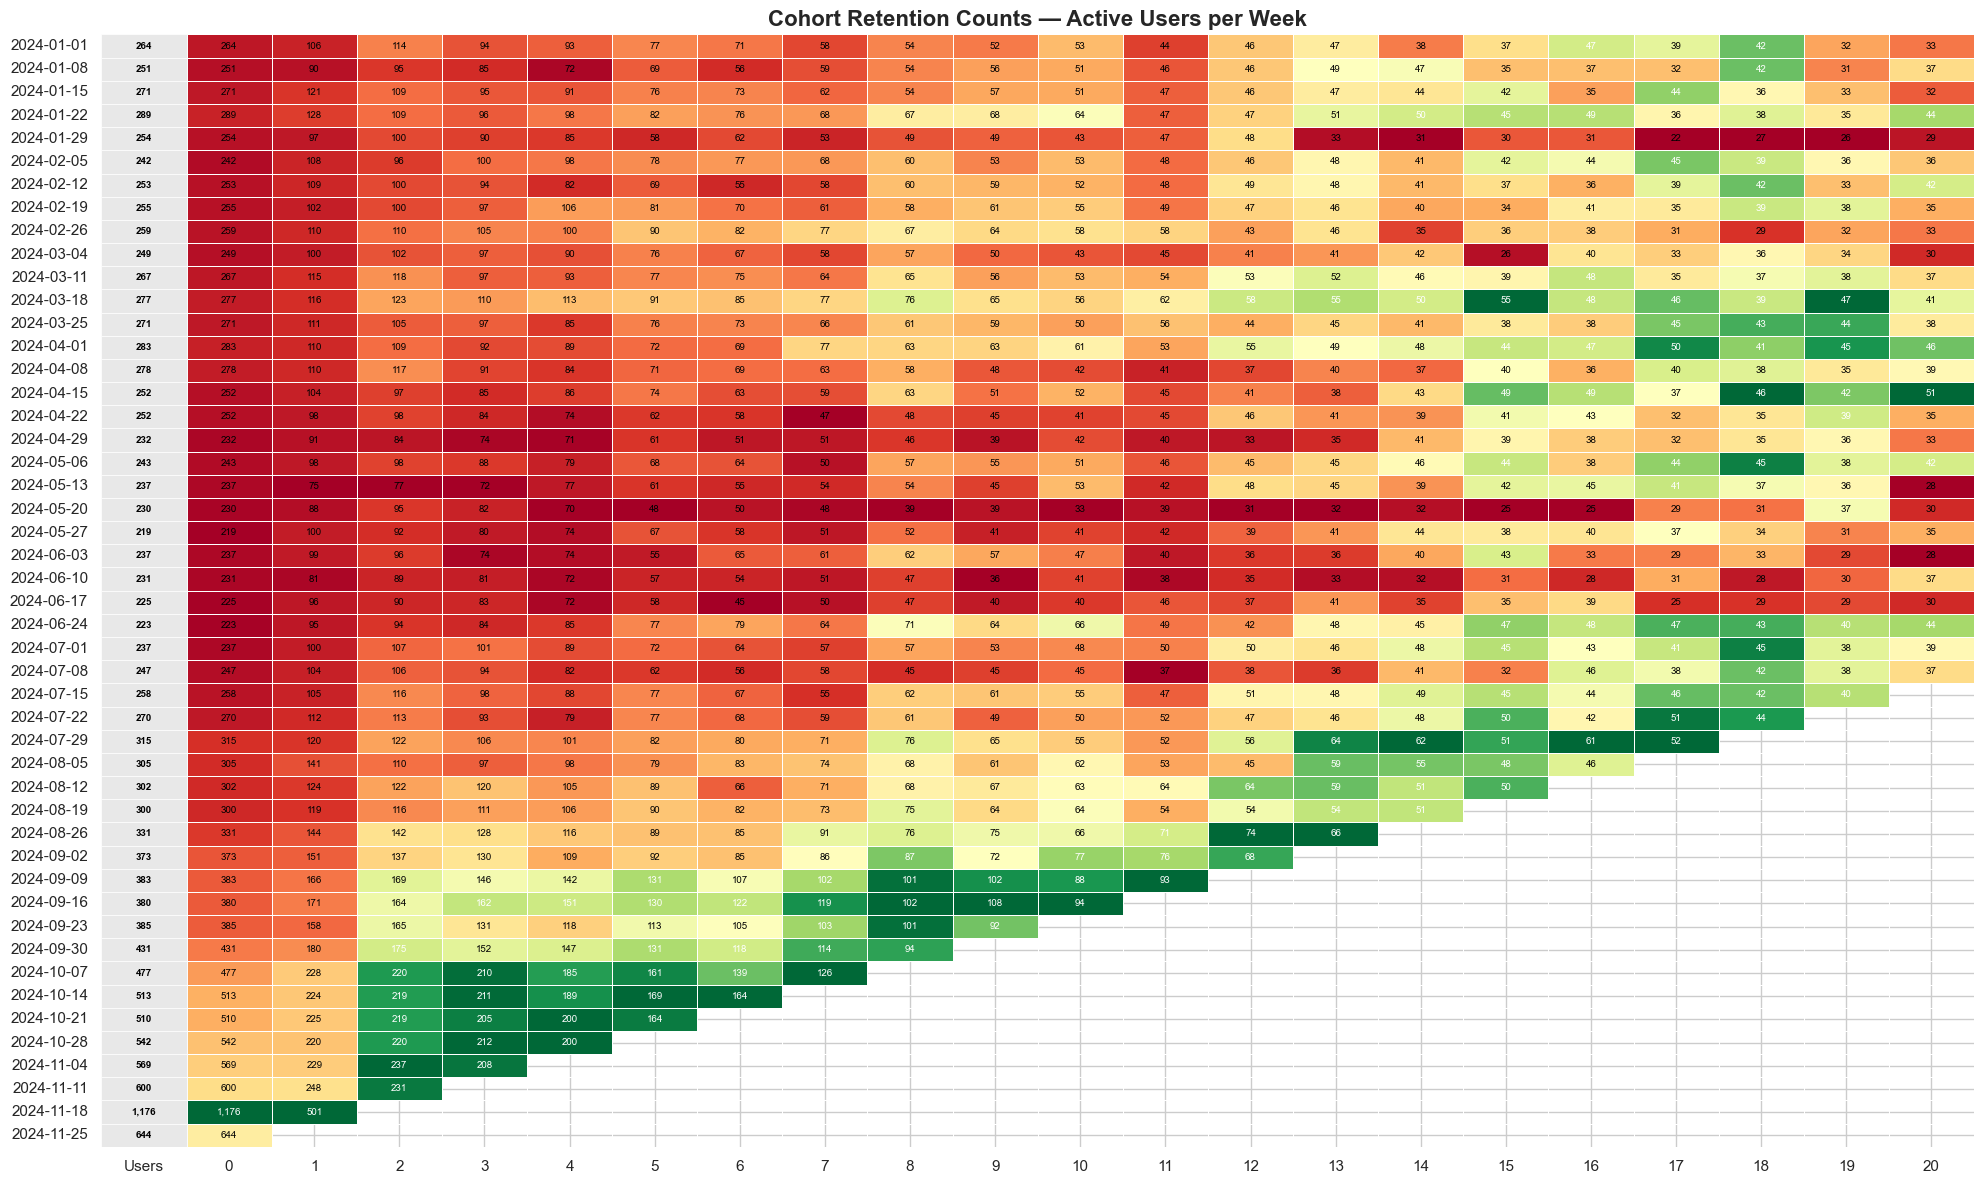

In [14]:
# Weekly retention rate heatmap
fig, ax = retention_counts_heatmap(df, granularity='weekly')

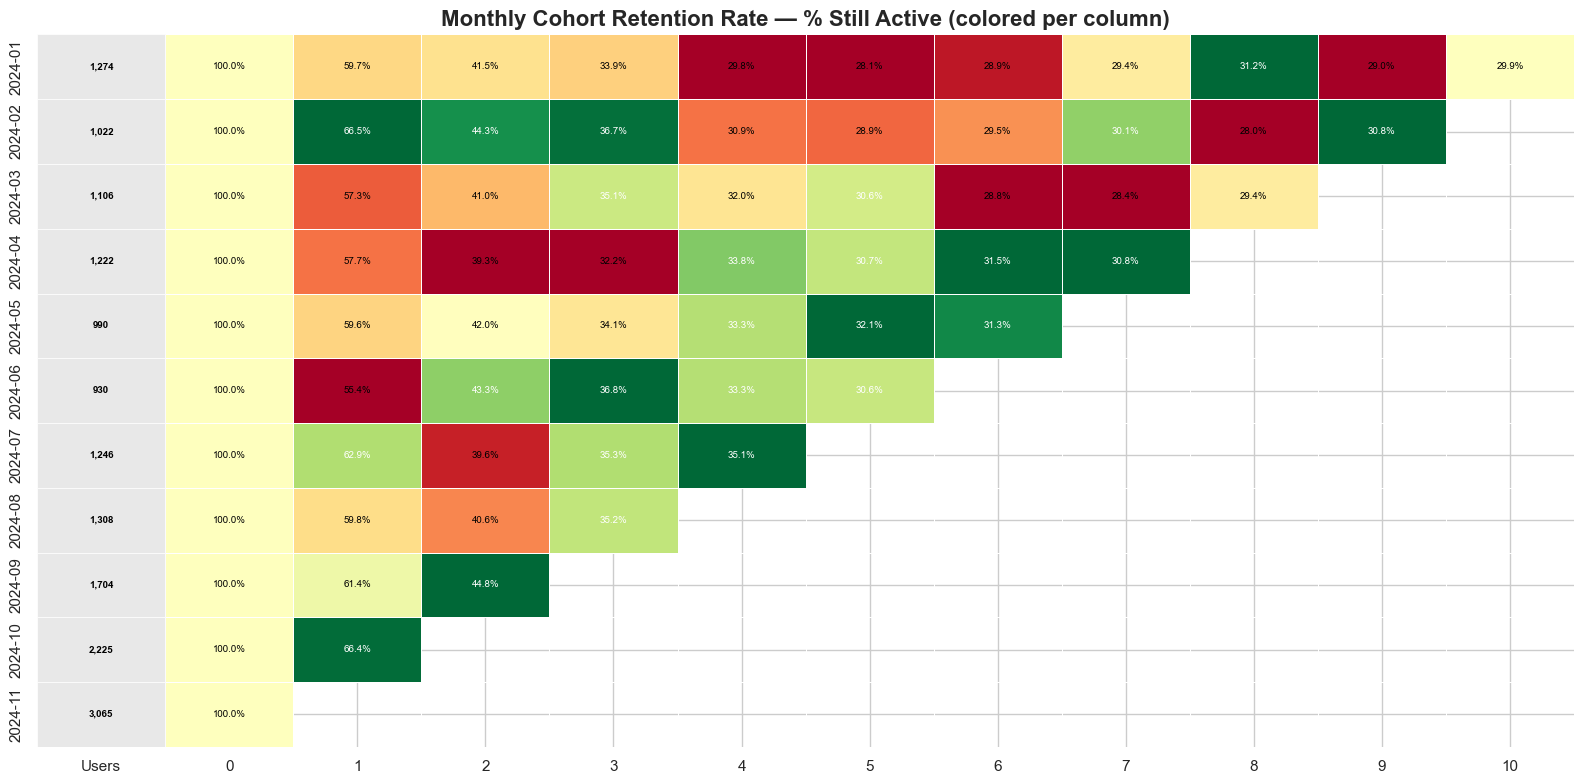

In [10]:
# Weekly retention rate heatmap
fig, ax = retention_rate_heatmap(df, granularity='month')

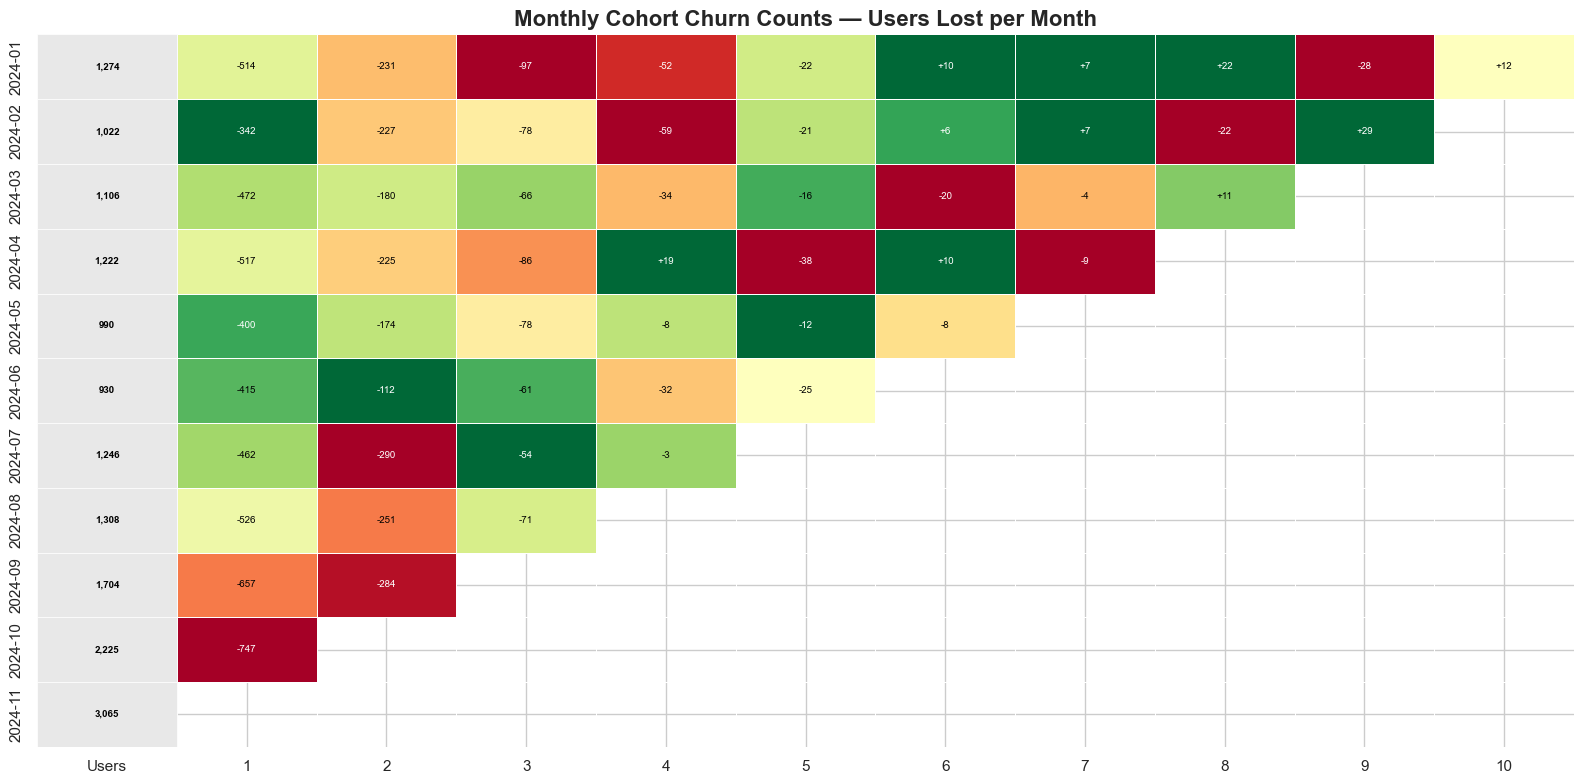

In [11]:
# Weekly retention rate heatmap
fig, ax = churn_counts_heatmap(df, granularity='month')

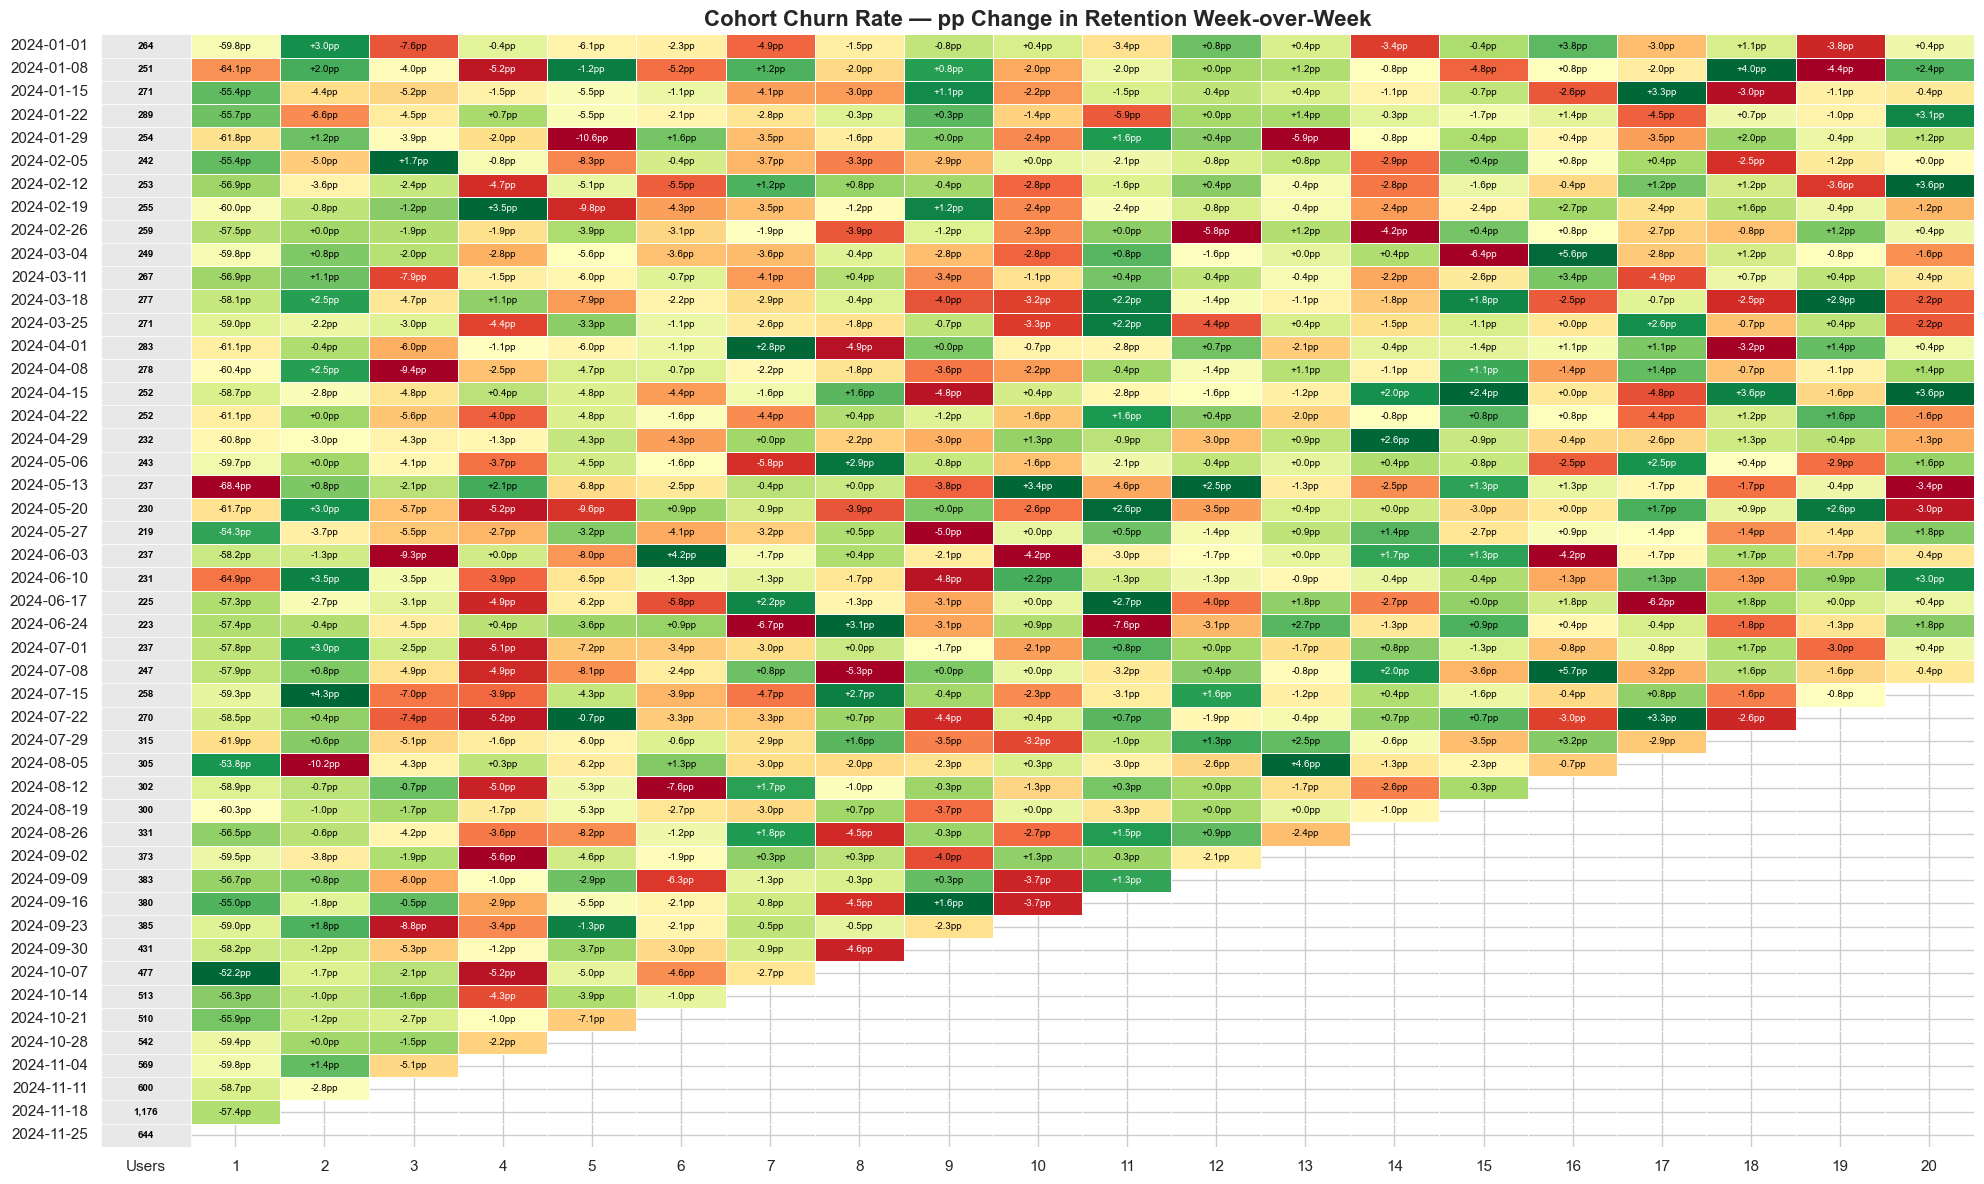

In [12]:
# Weekly retention rate heatmap
fig, ax = churn_rate_heatmap(df, granularity='week')

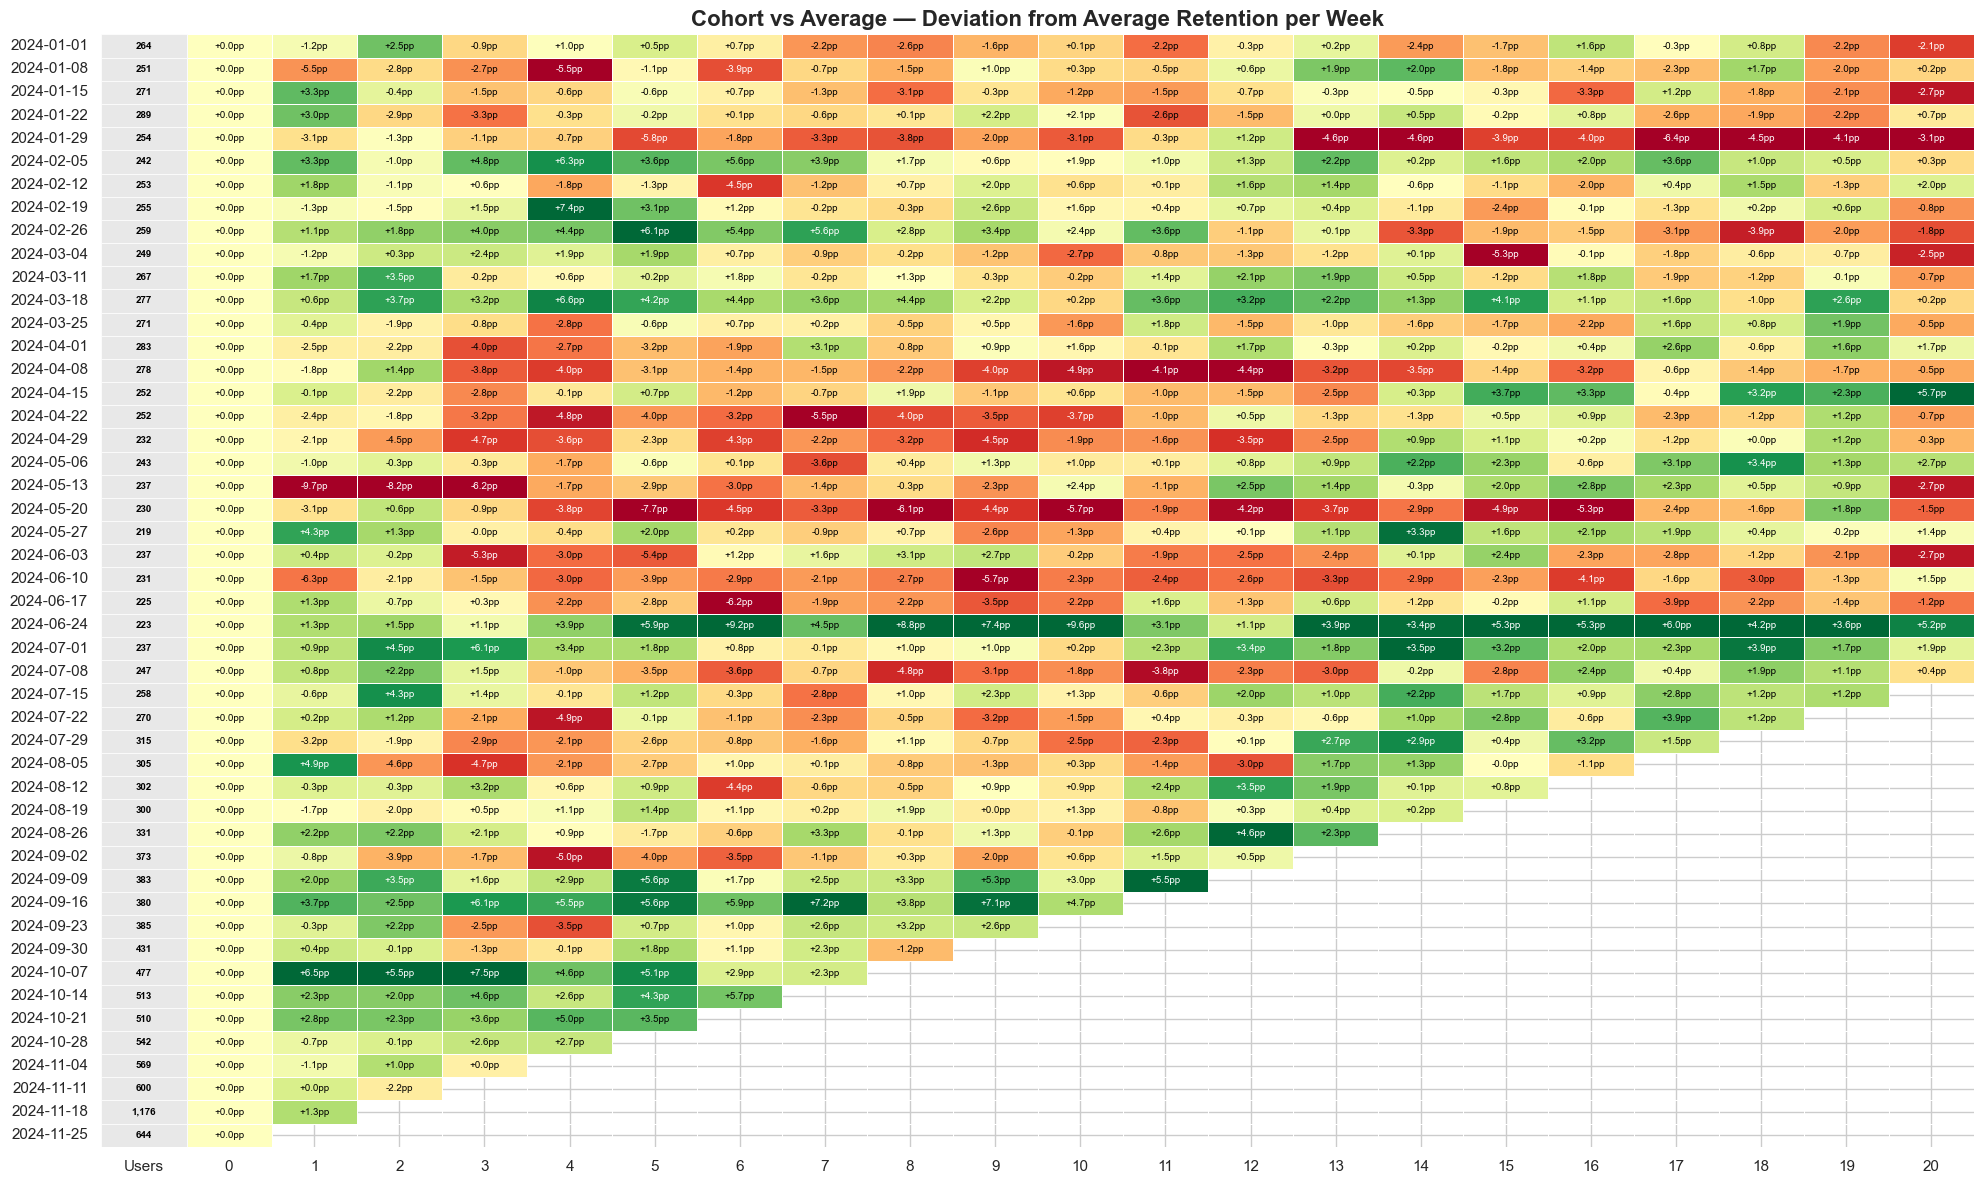

In [13]:
# Weekly retention rate heatmap
fig, ax = vs_average_heatmap(df, granularity='weekly')